# A mercury thermometer, and why not a water one

**Skills: entering tabulated data, plotting, numerical differentiation.** Work through
*Getting started with Python and Jupyter* first if you have not already.

A liquid-in-glass thermometer works because the liquid expands when it is warmed. Calibrate
it at two known temperatures — say the ice point and the steam point — mark the scale off in
equal divisions between them, and read the temperature from how far up the tube the liquid
has risen.

That last step hides an assumption: **that the liquid's volume is a straight line in
temperature.** It is not, for any real liquid. This notebook measures how much that costs
for mercury, and then shows what happens if you try the same thing with water.

The data are volumes of one gram of each fluid, from R. H. Perry and D. Green, eds.,
*Chemical Engineers' Handbook*, 6th ed., McGraw-Hill, New York, 1984, pp. 3-75–3-77. It is
the table printed with Problem 1.2.

## 1. The data

Two things to notice before you type anything in. The temperature spacing **changes** —
every degree from 0 to 10 °C, then every ten degrees to 100 °C — which will matter in §5.
And the water volumes are given to **seven** decimal places, which is a hint that something
interesting is happening in digits you would normally throw away.

| $T$ (°C) | volume of 1 g H₂O (cm³) | volume of 1 g Hg (cm³) |
|:---:|:---:|:---:|
| 0 | 1.0001329 | 0.0735560 |
| 1 | 1.0000733 | 0.0735694 |
| 2 | 1.0000321 | 0.0735828 |
| 3 | 1.0000078 | 0.0735961 |
| 4 | 1.0000000 | 0.0736095 |
| 5 | 1.0000081 | 0.0736228 |
| 6 | 1.0000318 | 0.0736362 |
| 7 | 1.0000704 | 0.0736496 |
| 8 | 1.0001236 | 0.0736629 |
| 9 | 1.0001909 | 0.0736763 |
| 10 | 1.0002719 | 0.0736893 |
| 20 | 1.0015678 | 0.0738233 |
| 30 | 1.0043408 | 0.0739572 |
| 40 | 1.0078108 | 0.0740910 |
| 50 | 1.0120740 | 0.0742250 |
| 60 | 1.0170460 | 0.0743592 |
| 70 | 1.0226940 | 0.0744936 |
| 80 | 1.0289870 | 0.0746282 |
| 90 | 1.0359040 | 0.0747631 |
| 100 | 1.0434270 | 0.0748981 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Temperature in degrees Celsius. Note the change of step at 10 C.
T = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
              20, 30, 40, 50, 60, 70, 80, 90, 100], dtype=float)

# Volume of one gram, cm^3. This is the SPECIFIC volume, V-hat in the book's notation.
V_water = np.array([1.0001329, 1.0000733, 1.0000321, 1.0000078, 1.0000000,
                    1.0000081, 1.0000318, 1.0000704, 1.0001236, 1.0001909,
                    1.0002719, 1.0015678, 1.0043408, 1.0078108, 1.0120740,
                    1.0170460, 1.0226940, 1.0289870, 1.0359040, 1.0434270])

V_hg = np.array([0.0735560, 0.0735694, 0.0735828, 0.0735961, 0.0736095,
                 0.0736228, 0.0736362, 0.0736496, 0.0736629, 0.0736763,
                 0.0736893, 0.0738233, 0.0739572, 0.0740910, 0.0742250,
                 0.0743592, 0.0744936, 0.0746282, 0.0747631, 0.0748981])

print(f"{len(T)} temperatures, {len(V_water)} water volumes, {len(V_hg)} mercury volumes")

20 temperatures, 20 water volumes, 20 mercury volumes


That `print` is not decoration. Typing twenty numbers into three arrays by hand is exactly
the operation in which you drop one, and an array of 19 volumes against 20 temperatures
fails later, in a confusing place. Check the lengths at the point where you enter the data.

## 2. Look at the data before you calculate anything

The two fluids differ in specific volume by a factor of fourteen, so plotting them on one
set of axes wastes both. Two panels side by side, sharing the temperature axis.

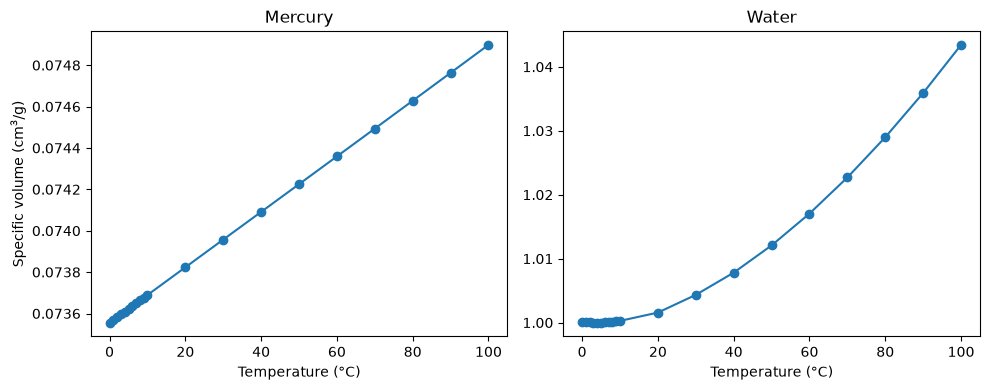

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax1.plot(T, V_hg, "o-")
ax1.set_ylabel("Specific volume (cm$^3$/g)")
ax1.set_title("Mercury")

ax2.plot(T, V_water, "o-")
ax2.set_title("Water")

for ax in (ax1, ax2):
    ax.set_xlabel("Temperature (°C)")
fig.tight_layout()
plt.show()

Mercury looks like a straight line. Water does not — it has a **minimum**, and the
tabulated minimum is exactly at 4 °C, where the volume is 1.0000000 cm³/g. (That is not a
coincidence: the gram was originally defined so that a cubic centimeter of water at its
densest weighed one.) Below 4 °C water *expands* as it cools, which is why lakes freeze
from the top and why the ice in them floats.

Neither observation is quantitative yet. Both plots are dominated by the overall rise, and
the interesting behavior of both fluids is in the departure from a straight line — which
is far too small to see here. The rest of the notebook is about extracting it.

## 3. What the thermometer actually reads

Calibrate at 0 °C and 100 °C and mark equal divisions between. The instrument then reports

$$T_\text{read} = 100 \times
  \frac{\hat{V}(T) - \hat{V}(0)}{\hat{V}(100) - \hat{V}(0)},$$

which is a straight line through the two calibration points **by construction**. The error
$\Delta T = T_\text{read} - T$ is therefore zero at 0 and 100 °C no matter what the fluid
does in between — so if your error plot does not pass through zero at both ends, you have a
bug, not a result. That is a free check, and it is worth having one in every calculation.

In [3]:
T_read = 100.0 * (V_hg - V_hg[0]) / (V_hg[-1] - V_hg[0])
error = T_read - T

worst = np.argmax(np.abs(error))
print(f"largest error: {error[worst]:+.4f} °C, at {T[worst]:.0f} °C")
print(f"error at the calibration points: {error[0]:+.2e} and {error[-1]:+.2e} °C")

largest error: -0.1535 °C, at 60 °C
error at the calibration points: +0.00e+00 and +0.00e+00 °C


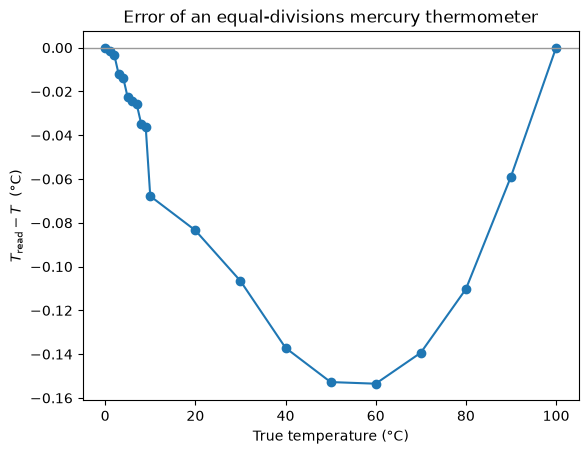

In [4]:
fig, ax = plt.subplots()
ax.plot(T, error, "o-")
ax.axhline(0.0, color="0.6", lw=1)
ax.set_xlabel("True temperature (°C)")
ax.set_ylabel("$T_\\mathrm{read} - T$  (°C)")
ax.set_title("Error of an equal-divisions mercury thermometer")
plt.show()

**About 0.15 °C too low, worst at 60 °C**, and negative everywhere in between: the
volume-versus-temperature curve bows very slightly *above* the straight line joining its
ends, so the liquid is always a little further up the tube than the linear scale claims.

Whether 0.15 °C matters depends entirely on what you are doing. It is far too large for
calibration work and utterly irrelevant for a fever. The number is the answer; deciding
whether it is acceptable is engineering.

**The kink at 10 °C is in the data, not in your arithmetic.** Every one-degree step in the
mercury table is $1.33$ or $1.34 \times 10^{-5}$ cm³/g except the last one, 9 to 10 °C,
which is $1.30 \times 10^{-5}$ — so the dense part of the table and the coarse part do not
quite join. Published tables are assembled from more than one source and rounded more than
once, and seams like this are ordinary. Worth knowing that a feature in your plot can come
from the table rather than from the physics.

## 4. The same thermometer, filled with water

Mercury's departure from linearity is a fraction of a degree. Now do the identical
calculation for water — calibrated over 0 to 10 °C, since that is where the table is
dense.

In [5]:
near = T <= 10.0
T_w, V_w = T[near], V_water[near]

T_read_water = 100.0 * (V_w - V_w[0]) / (V_w[-1] - V_w[0])

print(f"{'true T (°C)':>12}{'thermometer reads':>20}")
for t, r in zip(T_w, T_read_water):
    print(f"{t:12.0f}{r:20.1f}")

 true T (°C)   thermometer reads
           0                 0.0
           1               -42.9
           2               -72.5
           3               -90.0
           4               -95.6
           5               -89.8
           6               -72.7
           7               -45.0
           8                -6.7
           9                41.7
          10               100.0


This is not a thermometer that is inaccurate. It is **not a thermometer at all.**

Warm the water from 0 °C and the instrument reads *downwards*, reaching −96 before it turns
round and comes back. The reason is the minimum at 4 °C: one volume corresponds to **two**
temperatures, so no scale — however cleverly marked — can tell you which one you have. A
measuring device has to be single-valued in the thing it measures, and water's volume is
not, over this range.

Mercury's 0.15 °C is a calibration problem. Water's is a physics problem, and no
calibration fixes it.

## 5. Thermal expansion, by differences

The property behind all of this is the coefficient of thermal expansion,

$$\alpha = \frac{1}{\hat{V}}\left(\frac{\partial \hat{V}}{\partial T}\right)_P,$$

a derivative — and all we have is a table. So approximate the derivative by a **central
difference**: the slope of the line joining the point before to the point after,

$$\left(\frac{\partial \hat{V}}{\partial T}\right)_i \approx
  \frac{\hat{V}_{i+1} - \hat{V}_{i-1}}{T_{i+1} - T_{i-1}}.$$

**Divide by the actual temperature difference, not by a step size you assumed.** This
table steps by 1 °C up to 10 °C and by 10 °C after that. Writing the textbook formula with
a constant $h$ gives an answer that is wrong by a factor of ten over most of the range, and
nothing in the output will look wrong — it is a plausible number of the wrong size.

In [6]:
def alpha(V, T):
    """Thermal expansion coefficient by central differences. Handles uneven spacing."""
    dVdT = np.empty_like(V)
    dVdT[1:-1] = (V[2:] - V[:-2]) / (T[2:] - T[:-2])     # central, inside
    dVdT[0] = (V[1] - V[0]) / (T[1] - T[0])              # one-sided, at the ends
    dVdT[-1] = (V[-1] - V[-2]) / (T[-1] - T[-2])
    return dVdT / V


alpha_hg = alpha(V_hg, T)
alpha_water = alpha(V_water, T)

# NumPy has this built in, and it is worth checking a routine you wrote against it.
print("max difference from np.gradient:",
      f"{np.max(np.abs(alpha_hg - np.gradient(V_hg, T) / V_hg)):.1e} 1/K")

print(f"\nmercury: alpha from {alpha_hg.min():.3e} to {alpha_hg.max():.3e} 1/K "
      f"({100 * (alpha_hg.max() - alpha_hg.min()) / alpha_hg.mean():.1f}% variation)")
print(f"water at 4 °C:   {alpha_water[4]:+.3e} 1/K")
print(f"water at 0 °C:   {alpha_water[0]:+.3e} 1/K")
print(f"water at 50 °C:  {alpha_water[14]:+.3e} 1/K")

max difference from np.gradient: 4.4e-06 1/K

mercury: alpha from 1.792e-04 to 1.822e-04 1/K (1.7% variation)
water at 4 °C:   +1.500e-07 1/K
water at 0 °C:   -5.959e-05 1/K
water at 50 °C:  +4.563e-04 1/K


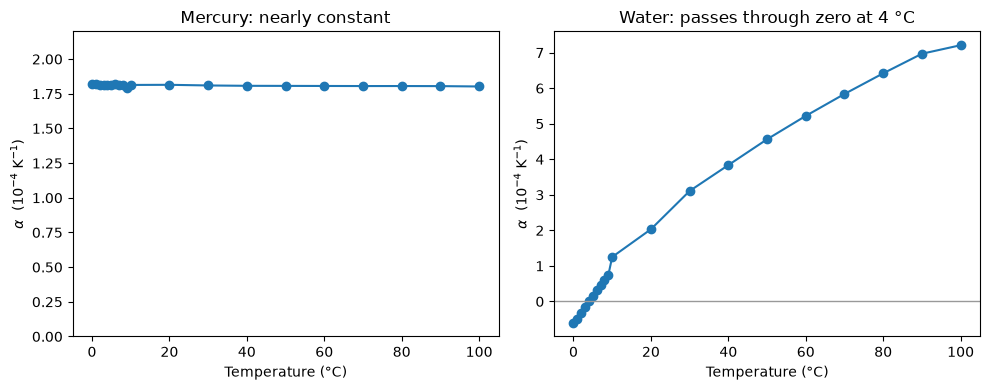

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax1.plot(T, alpha_hg * 1e4, "o-")
ax1.set_ylim(0, 2.2)
ax1.set_title("Mercury: nearly constant")

ax2.plot(T, alpha_water * 1e4, "o-")
ax2.axhline(0.0, color="0.6", lw=1)
ax2.set_title("Water: passes through zero at 4 °C")

for ax in (ax1, ax2):
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel(r"$\alpha$  ($10^{-4}$ K$^{-1}$)")
fig.tight_layout()
plt.show()

**This is the whole answer to "why mercury?"** Its expansion coefficient varies by under
2% across the entire range, so equal divisions of volume are very nearly equal divisions of
temperature. Water's changes sign.

Now the caveat, and it is the reason the table carries seven decimal places. The central
difference at 4 °C is built from the two entries either side of it:

$$\hat{V}(5) - \hat{V}(3) = 1.0000081 - 1.0000078 = 3\times10^{-7}\ \mathrm{cm^3/g}.$$

Six of the seven digits cancel. What survives is the **last** digit of the table, which is
itself uncertain by about $\pm 5\times10^{-8}$ — so a numerator of $3\times10^{-7}$ carries
roughly a 30% uncertainty, and so does $\alpha(4\ ^\circ\mathrm{C})$.

In [8]:
num = V_water[5] - V_water[3]
last_digit = 1e-7                      # the table's resolution

print(f"numerator V(5) - V(3)     = {num:.3e} cm^3/g")
print(f"uncertainty in it         = {last_digit:.0e} cm^3/g  (two entries, +/- half a digit each)")
print(f"relative uncertainty      = {100 * last_digit / num:.0f} %")
print(f"\nalpha(4 °C) = {alpha_water[4]:.2e} +/- {alpha_water[4] * last_digit / num:.1e} 1/K")

numerator V(5) - V(3)     = 3.000e-07 cm^3/g
uncertainty in it         = 1e-07 cm^3/g  (two entries, +/- half a digit each)
relative uncertainty      = 33 %

alpha(4 °C) = 1.50e-07 +/- 5.0e-08 1/K


Note what limits the answer here. It is **not** the central-difference formula — a finer
formula would not help. It is the data. Subtracting two nearly equal numbers destroys
precision, and no amount of arithmetic afterwards puts it back. When a calculation
differences tabulated values, ask how many digits actually survive the subtraction.

## What this notebook shows

- **A thermometer with equal divisions assumes the fluid expands linearly.** For mercury
  that costs 0.15 °C, worst near 60 °C; whether that matters is a separate question from
  what the number is.
- **Water cannot be used at all below about 8 °C** — its volume has a minimum at 4 °C, so
  the reading is not single-valued. Some measurement problems are not accuracy problems.
- **Mercury works because $\alpha$ is nearly constant**, varying about 1% from 0 to 100 °C.
  That is the property to look for, not a large expansion.
- **Differencing a table costs digits.** At 4 °C six of water's seven figures cancel, and
  $\alpha$ there is uncertain by 30% — a limit set by the data, not the method.
- Two habits worth keeping: check array lengths where you type data in, and look for a
  quantity your calculation must reproduce exactly (here, zero error at both calibration
  points).

## Your turn

1. Recalibrate the mercury thermometer at 0 °C and **50** °C instead of 0 and 100, and plot
   the error over the whole table. Is the worst error larger or smaller than before? Where
   is it now, and what happens above 50 °C?
2. Rewrite `alpha` using a **fixed** step of 1 °C, as the textbook formula is usually
   written, and plot it against the correct version. Above 10 °C the two differ by a factor
   of ten. Which one *looks* wrong?
3. Fit a straight line to the mercury data with `np.polyfit(T, V_hg, 1)` and plot the
   residuals — the differences between the data and the fit. Compare their shape with the
   error curve in §3. Should they look alike?
4. Water's expansion coefficient at 4 °C is zero, and §5 says the estimate there is
   uncertain by 30%. Does that uncertainty change your confidence in the *statement* that
   $\alpha$ passes through zero at 4 °C? Explain why, or why not.